In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
# Adding comment to test commit.

ceqSwitch = 'c1neqc2'
plotCont = True
IRT = 'IRT'
derivative = False
BooleAve = False
# field = 'B'
WaveFunc = WFT.Gauss#Packet
# appendage = '-' + ceqSwitch + '-' + contSwitch + '-' + IRT

k = 29

val2 = 0.25

gridBool = True
enlarge = True
fontsize = 14

In [3]:
nh_min = 32
refRatio = 2
CFL = np.sqrt(0.5)
# nt = 20
x_0 = 0.
x_1 = 0.5
Hans = False

deriv = 'CD'
RK = 4
order = 2

L = 1.
locs = []#x_1]
epsilons = [1]#, val2]# 11.68]
mus = [1]#, 1]#0.99837]

In [4]:
omegaAMR = BT.Grid(nh_min)
refCells = int(nh_min // 2)
finepart = list((np.arange(refCells) + int((nh_min / 2) - (refCells / 2))))
omegaAMR.AddPatch(refRatio, finepart)
degFreed = omegaAMR.degFreed
nh_max = omegaAMR.nh_max

omegaF = BT.Grid(nh_max)
omegaC = BT.Grid(nh_min)

hC = omegaC.h[0]

In [5]:
# c = ConvertParams(permitivity, permeability, L)
# t, nt = ST.CalcTime(omegaC, CFL, csAMR[0], nt = nt) # CHANGE BACK TO OMEGAAMR!!!
sigma, mu = WFT.GaussParams(x_0, x_1 / 2, deriv = derivative)
sigmaD, muD = WFT.GaussParams(0, 1, deriv = True)
wavesAMR = WT.MakeWaves(omegaAMR)
nullspace = OT.FindNullspace(omegaAMR, wavesAMR, Hans = Hans)
restrictOp = GTT.CoarsenOp(omegaAMR)

wavesF = WT.MakeWaves(omegaF)
wavesC = WT.MakeWaves(omegaC)

# derivMat = TT.ExactSpatOp(omegaAMR)
# spatOp = -cMatF @ derivMat
# timePropOp = LA2.expm(t * spatOp)

# derivMatC = TT.ExactSpatOp(omegaC)
# spatOpC = -cMatC @ derivMatC
# timePropOpC = LA2.expm(t * spatOpC)

# opC = -cMatC @ OT.SpaceDeriv(omegaC, order, diff)
# opF = -cMatF @ OT.SpaceDeriv(omegaF, order, diff)
# opAMR = -cMatAMR @ OT.SpaceDeriv(omegaAMR, order, diff)


/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:415: RuntimeWarning: divide by zero encountered in divide
  val1 = (alphRange ** 2) * (10 ** (errOrd / (alphRange ** 2)))
/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:415: RuntimeWarning: overflow encountered in power
  val1 = (alphRange ** 2) * (10 ** (errOrd / (alphRange ** 2)))
/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/WaveformTools.py:415: RuntimeWarning: invalid value encountered in multiply
  val1 = (alphRange ** 2) * (10 ** (errOrd / (alphRange ** 2)))


In [6]:
# # For Gaussian:
# waveInitC = WFT.Gauss(omegaC, physicsC, sigma, mu, BooleAve = False, deriv = False, cellAve = True)
# waveInitF = WFT.Gauss(omegaF, physicsF, sigma, mu)
args = [sigma, 3*mu]#, k]
args2 = [4*sigma, 4*mu, k]
args3 = [sigmaD, muD]


In [7]:
t_snaps = 5

filler = [[] for i in range(t_snaps)]
allCoefsC = [filler.copy() for i in range(3)]
allCoefsF = [filler.copy() for i in range(3)]
allCoefsAMR = [filler.copy() for i in range(3)]

maxC = 0
minC = 0
maxF = 0
minF = 0
maxAMR = 0
minAMR = 0
# allCoefsC [1][2] = 1
# print(allCoefsC)
# print(allCoefsF)
t_snaps = 1


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

indices: 0 0 E [] t = 0 t_snaps: 1

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

We're doing BoolesAve!
x is 129 long.

YOU ARE RUNNING GAUSS! False

We're doing BoolesAve!
x is 257 long.

YOU ARE RUNNING GAUSS! False

indices: 1 0 E [] t = 0 t_snaps: 1
We're doing BoolesAve!
x is 129 long.

YOU ARE RUNNING GAUSS! False

We're doing BoolesAve!
x is 257 long.

YOU ARE RUNNING GAUSS! False

We're doing BoolesAve!
x is 193 long.

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

indices: 2 0 EB [] t = 0 t_snaps: 1

YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True


YOU ARE RUNNING GAUSS! True

Coarse: -19.072536758944082 19.072536758944082
Fine: -20.29003103883953 20.29003103883953
AMR: -20.29003103883953 20.29003103883953

indices: 0 0
This image has been saved under /Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/FreqErrorFin

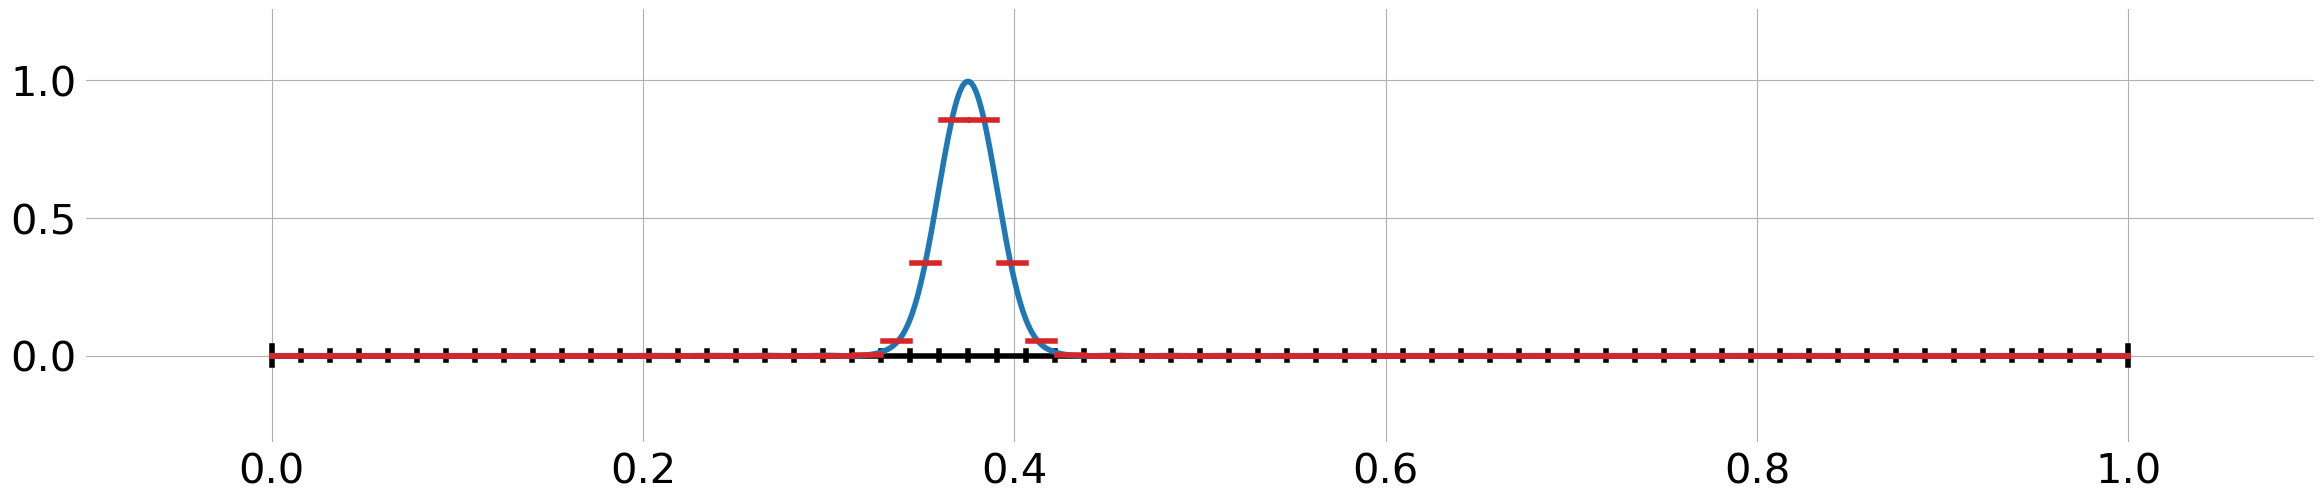

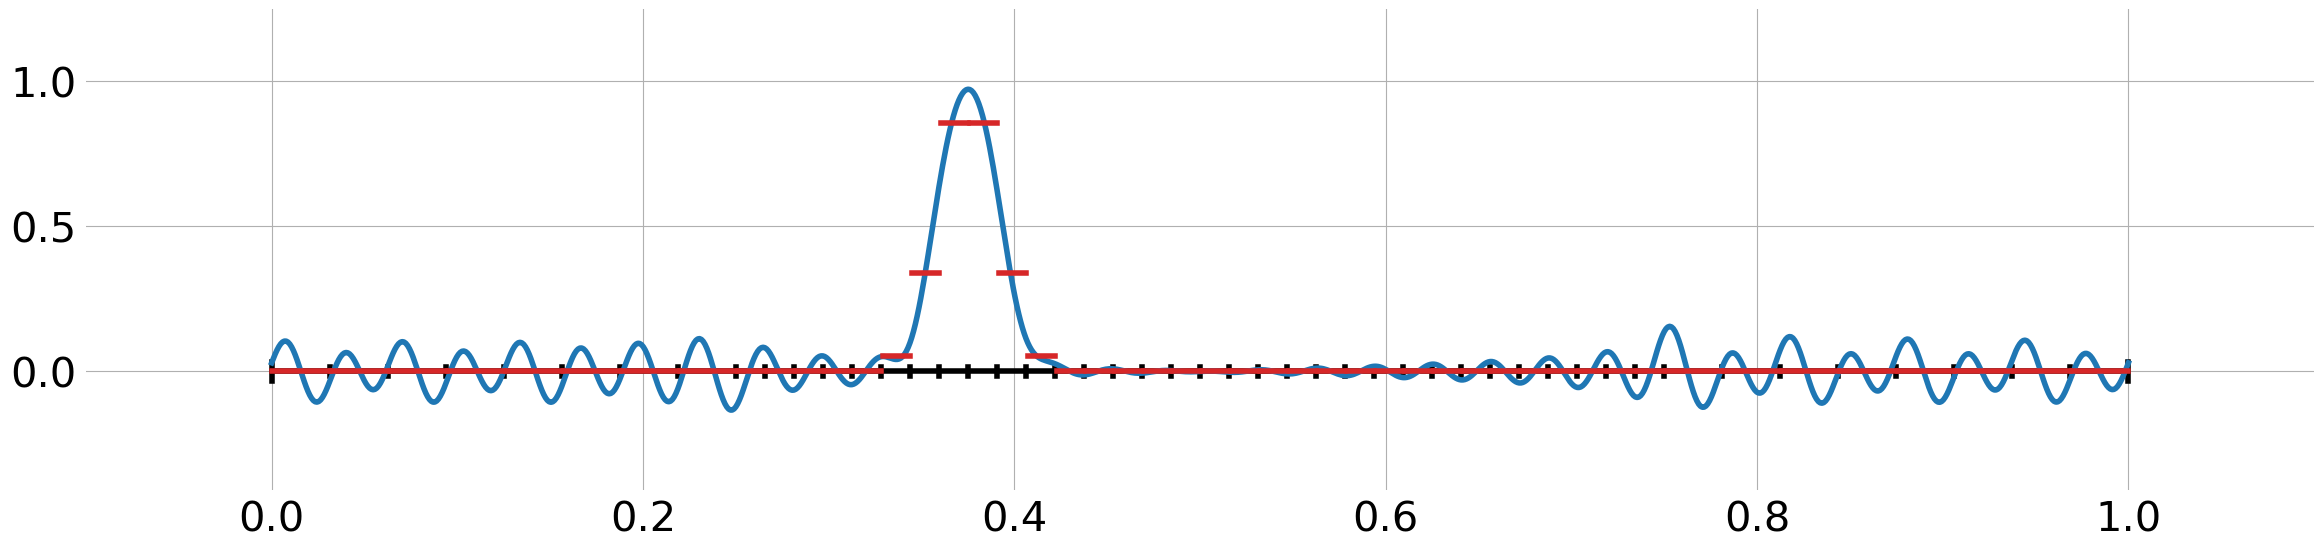

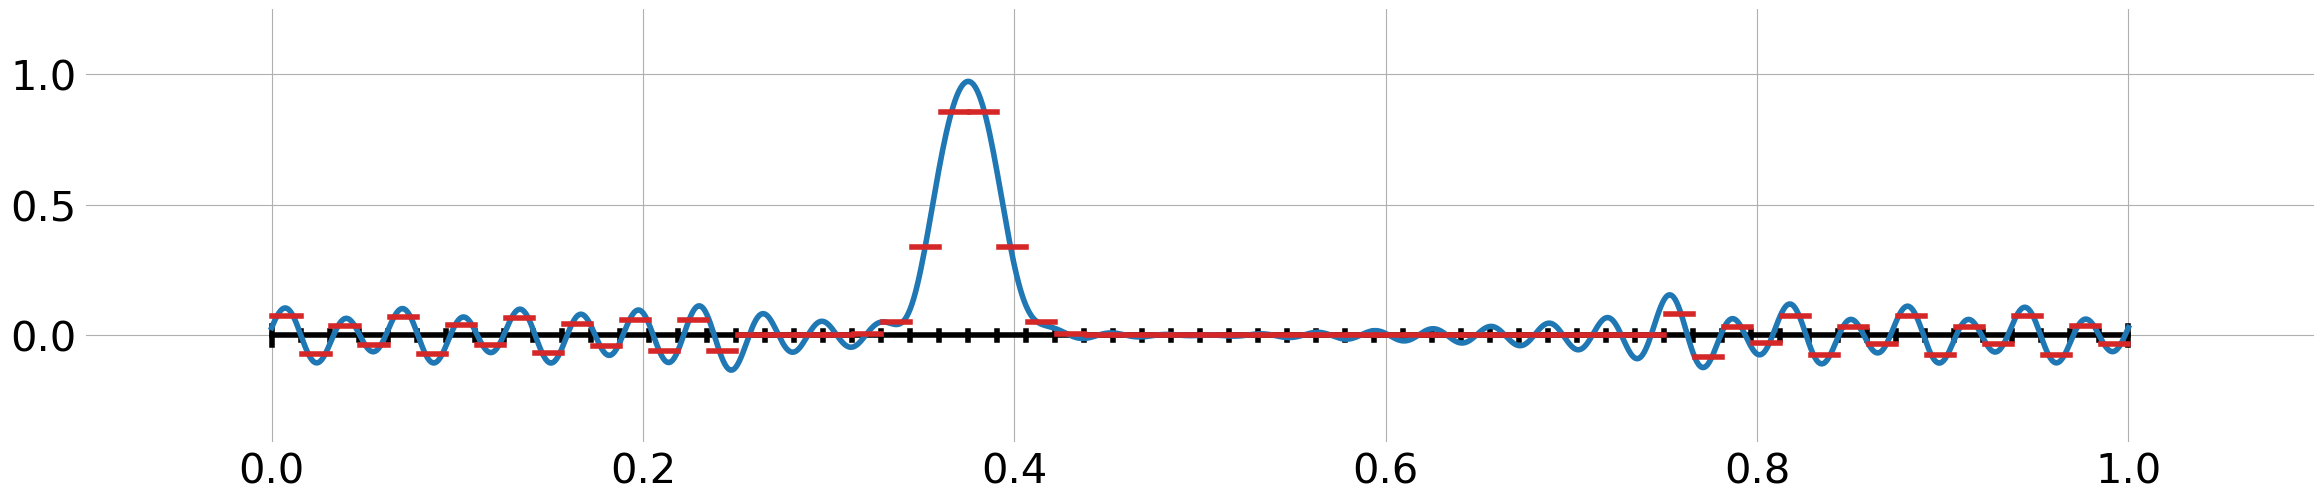

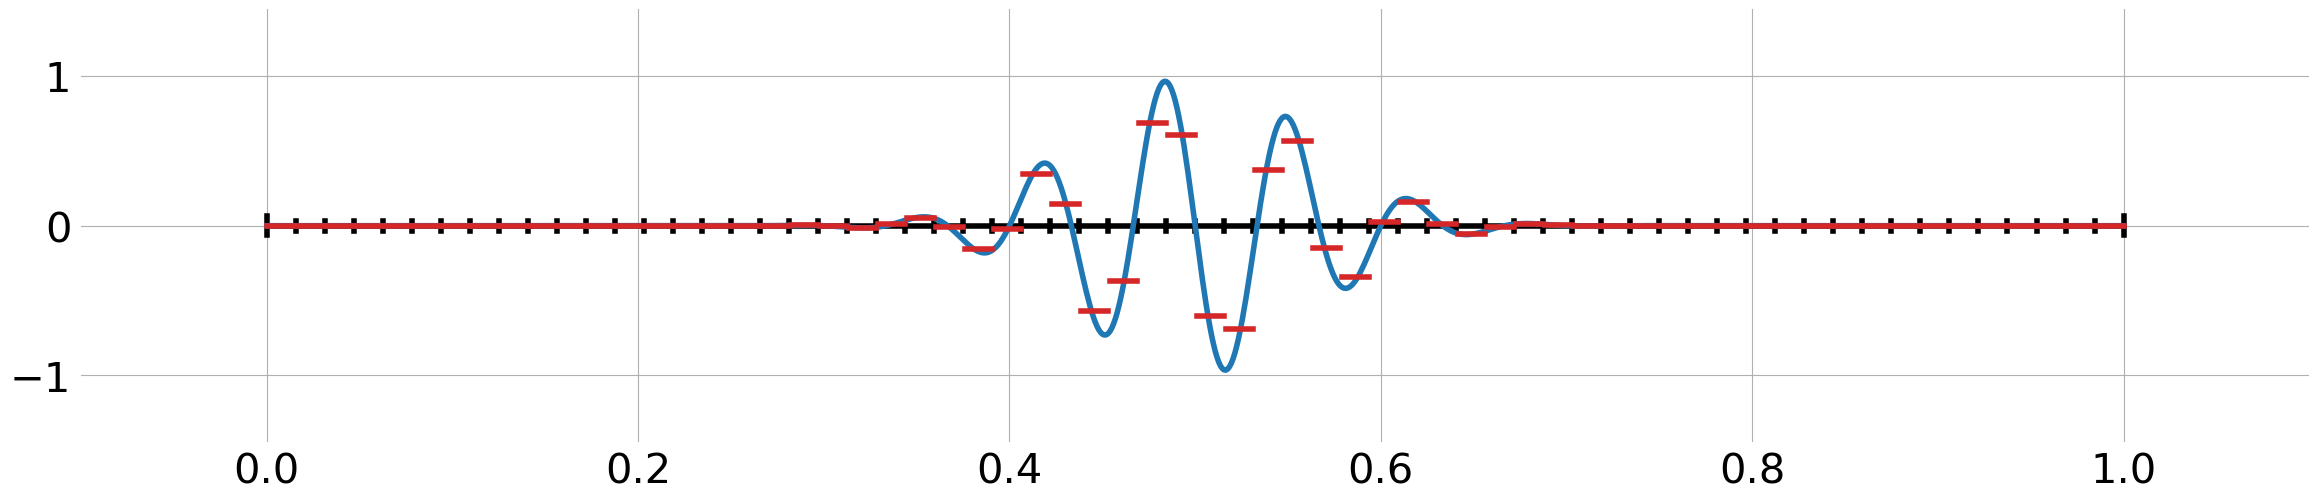

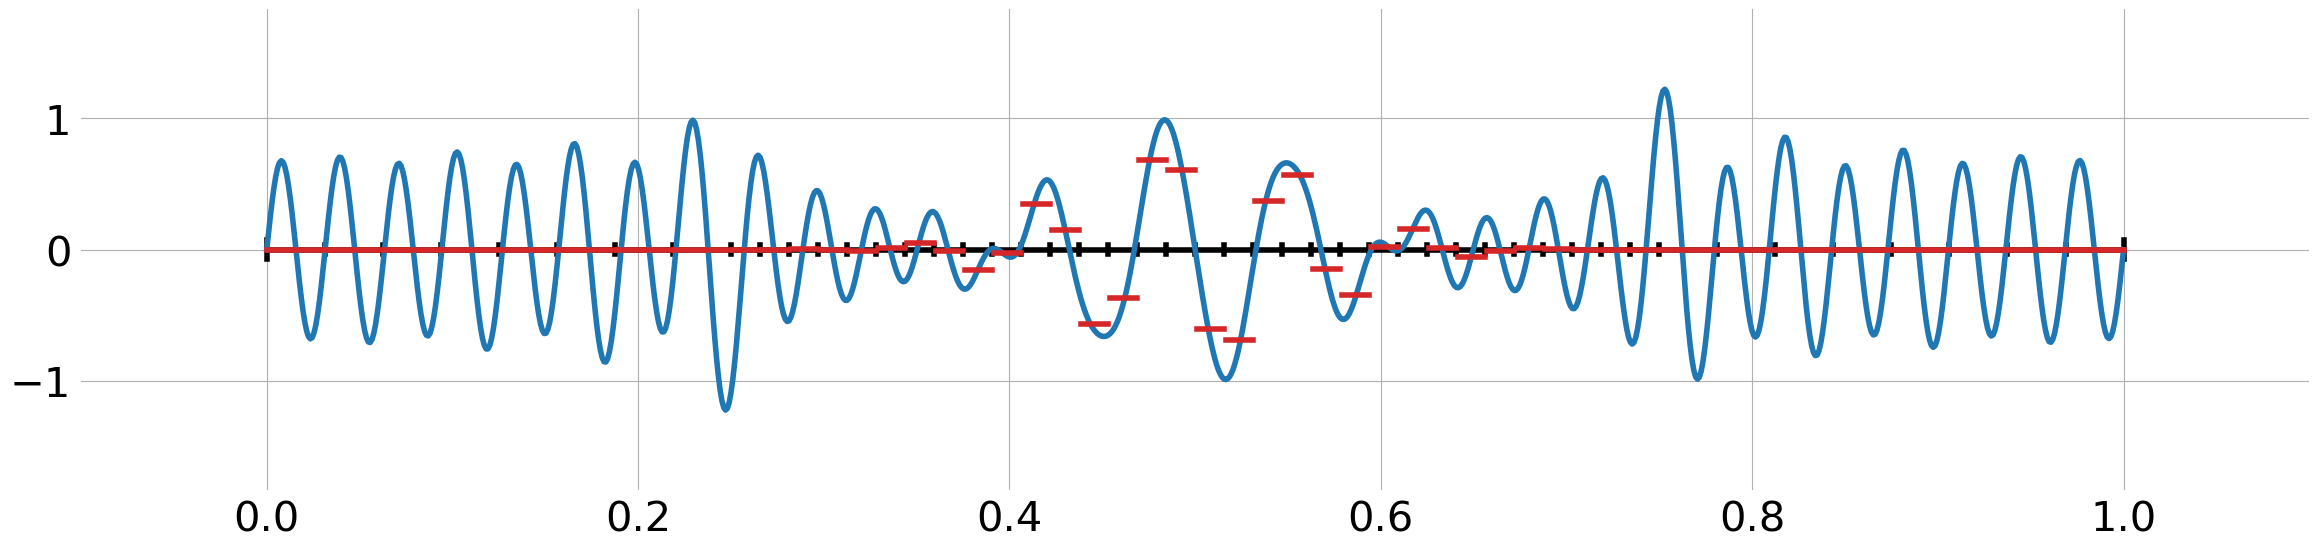

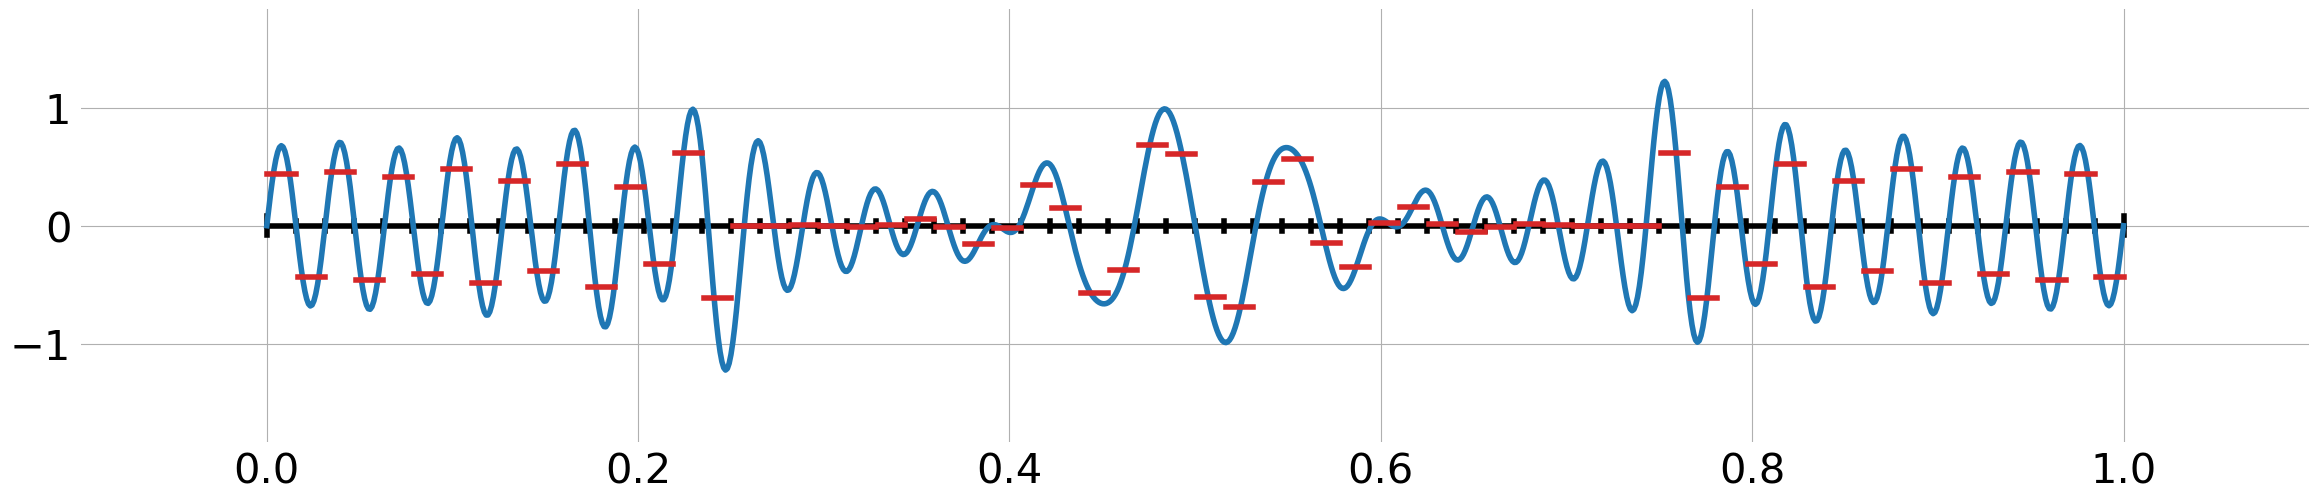

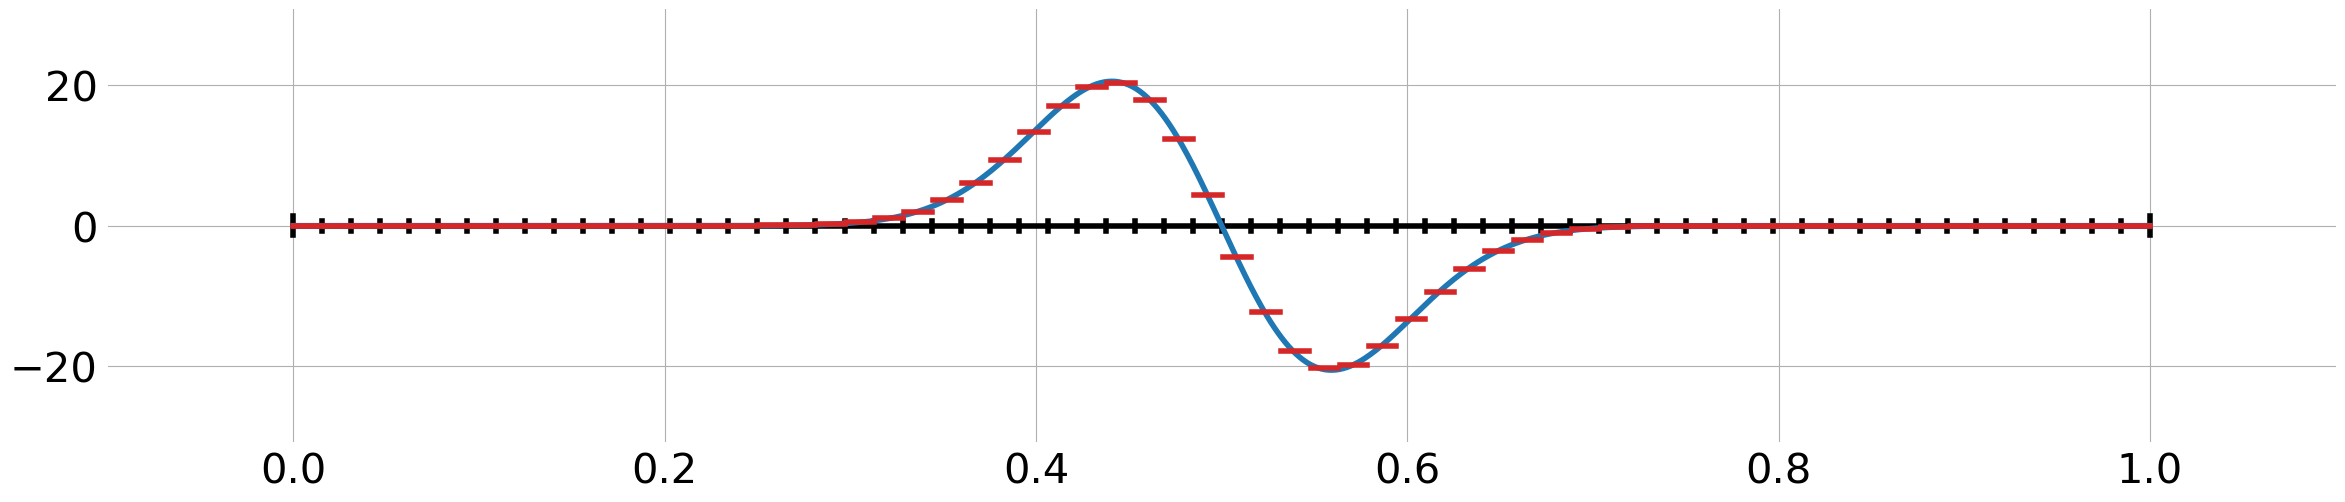

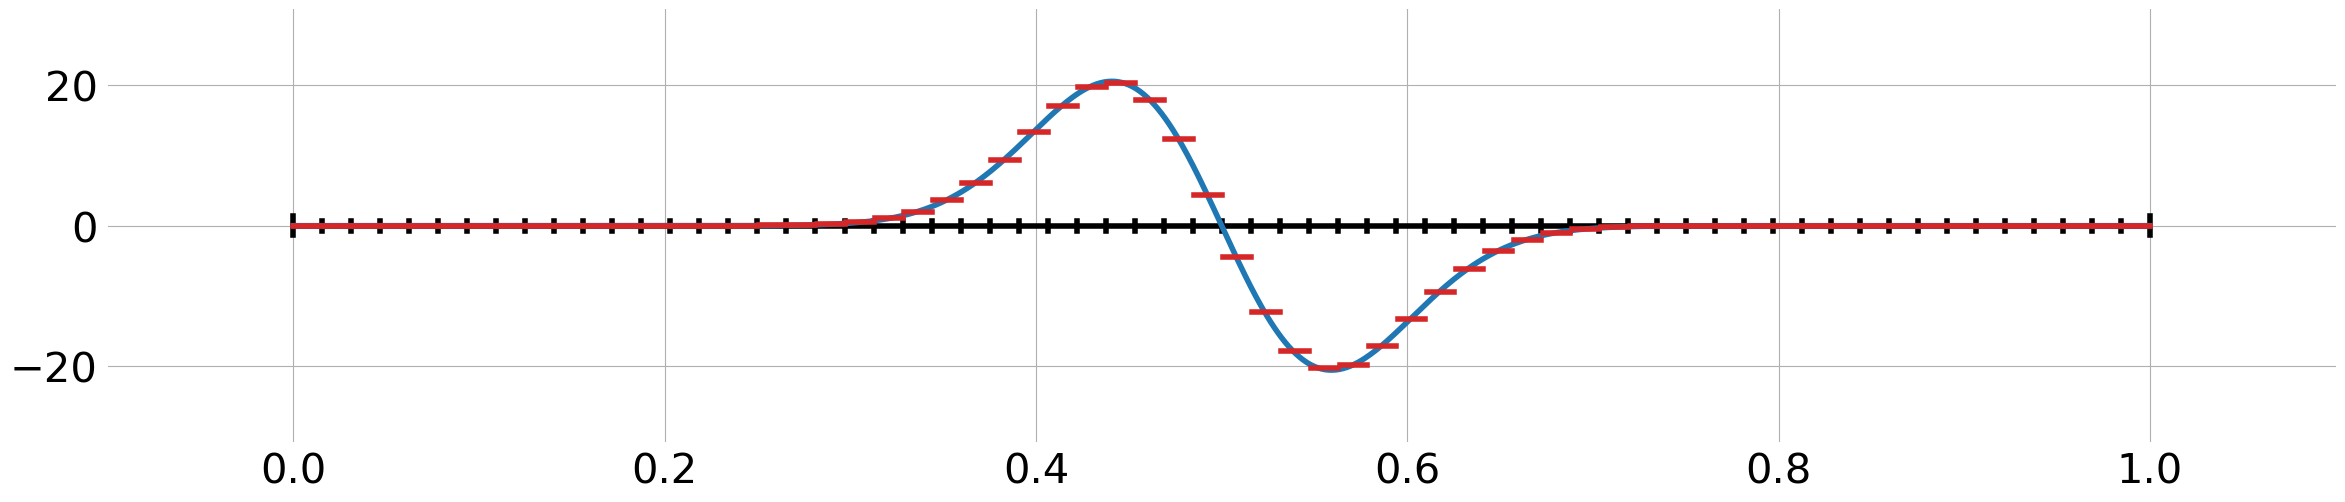

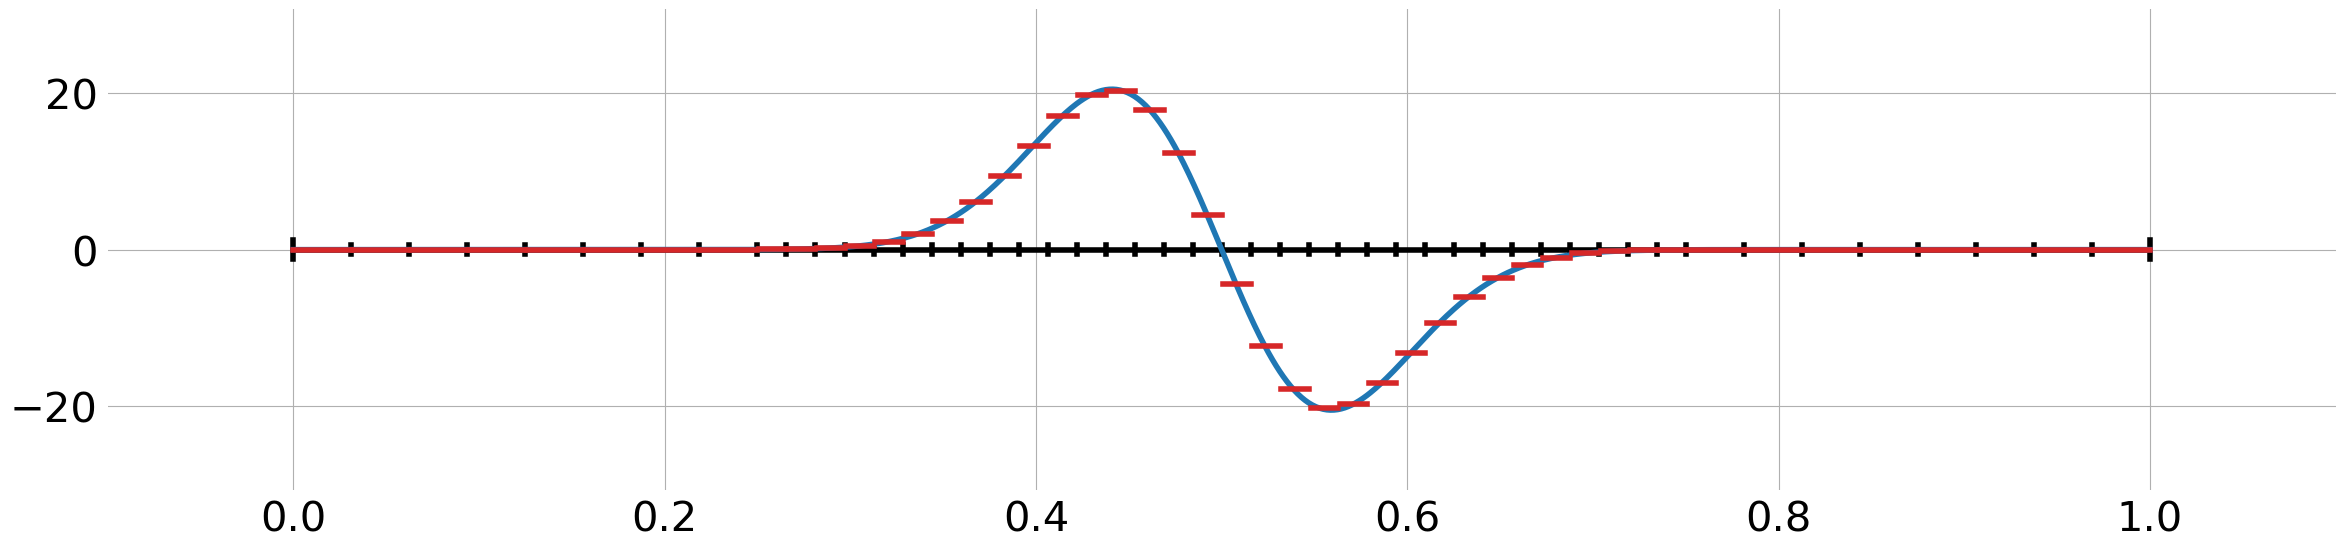

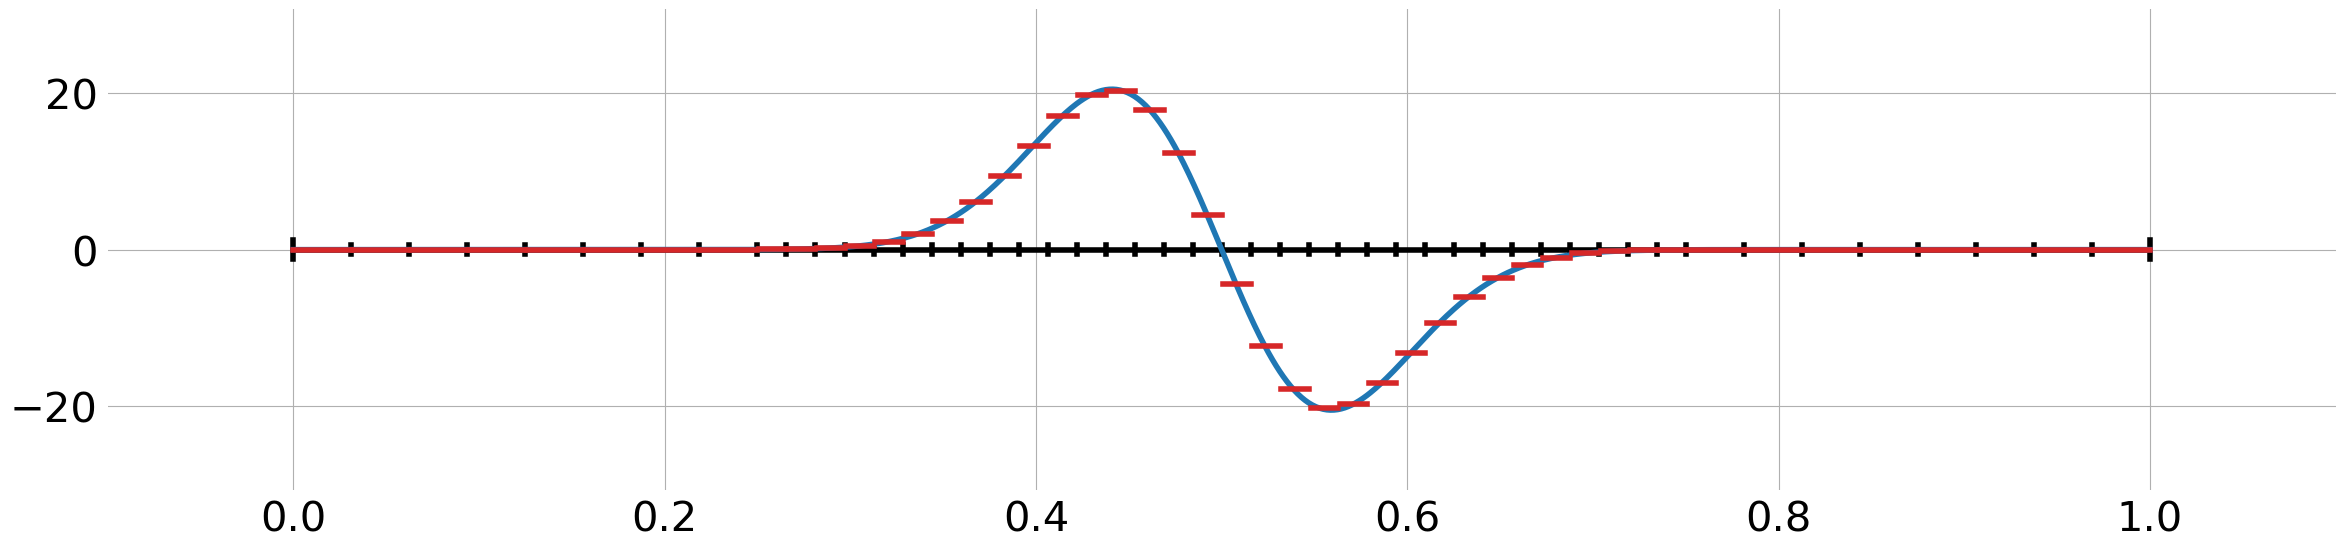

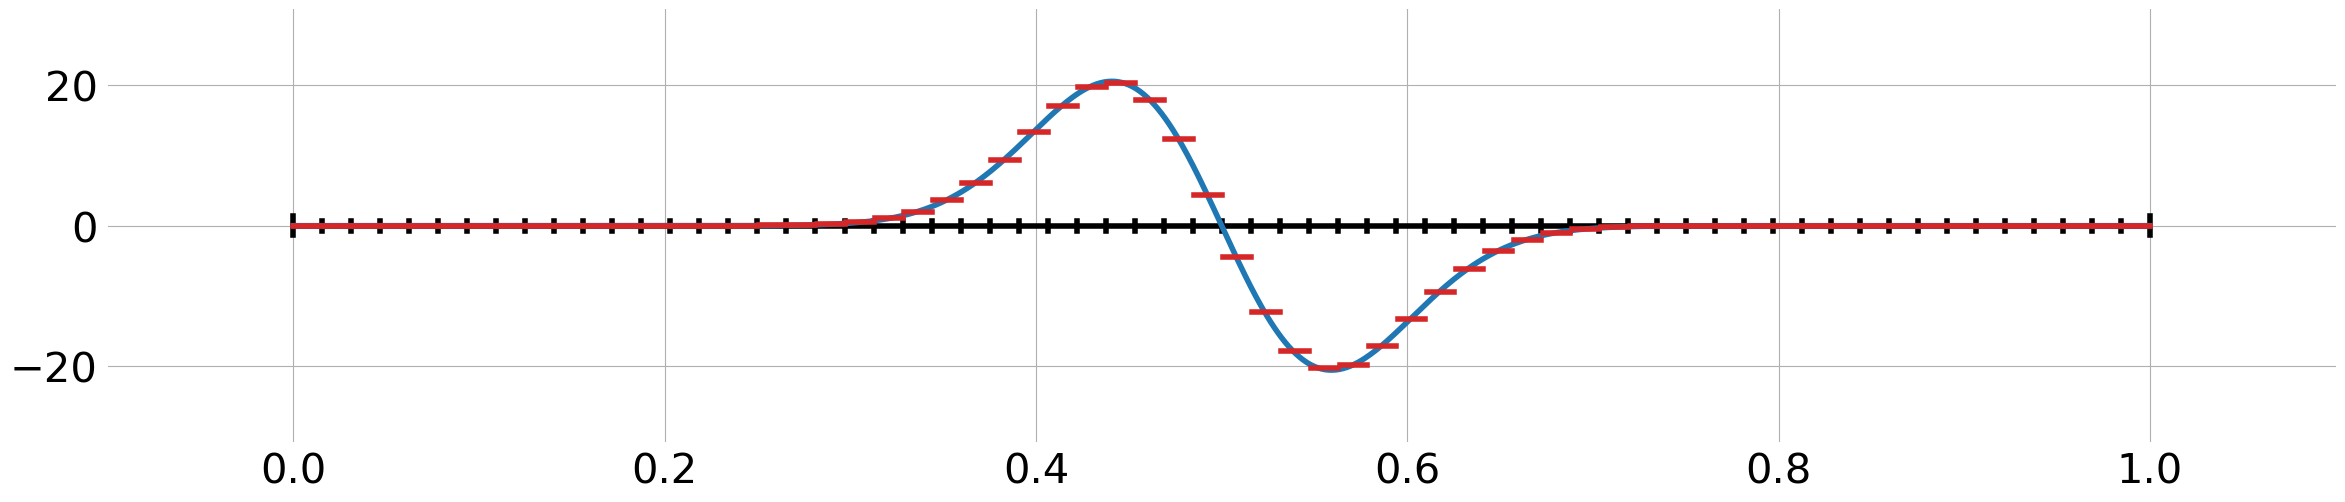

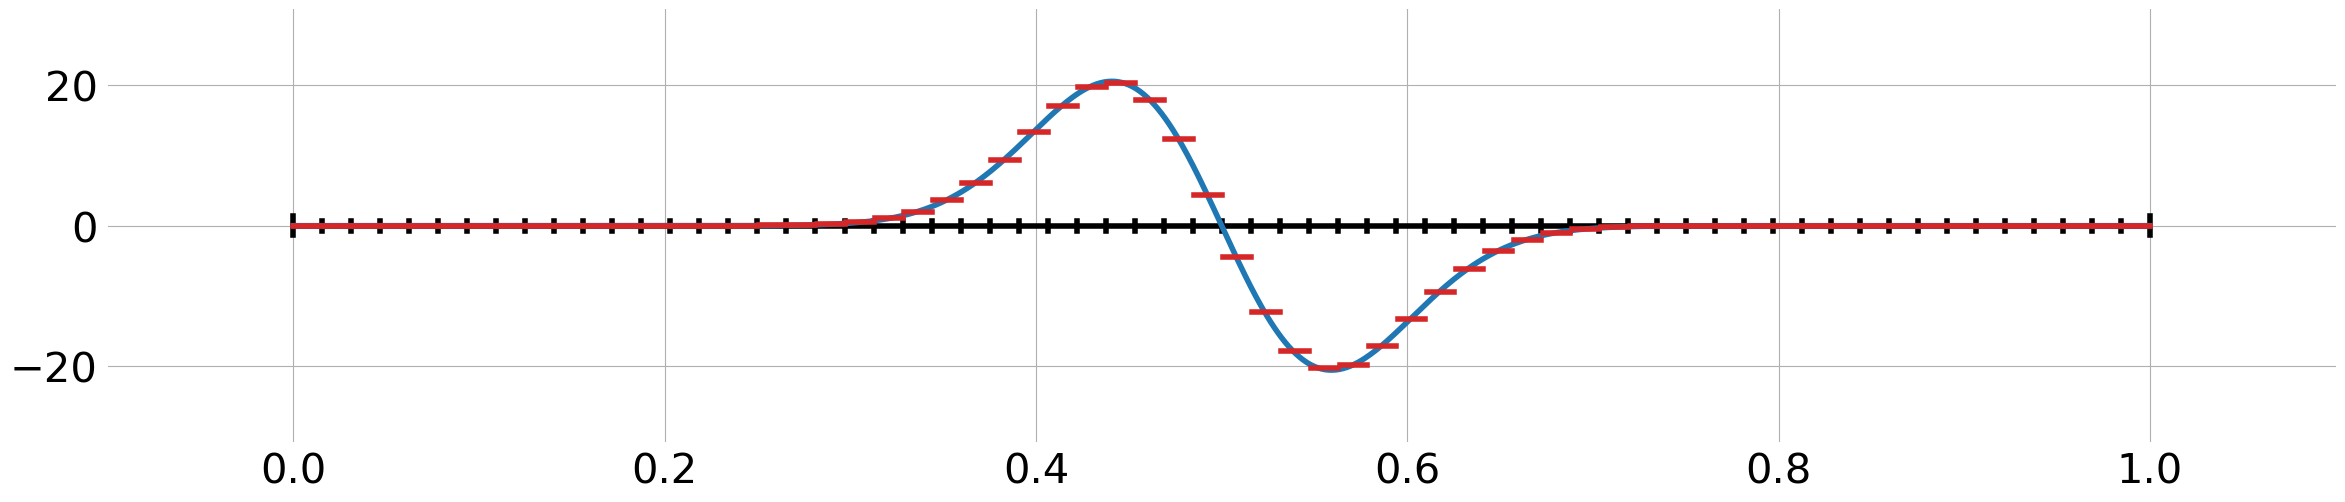

In [8]:
field = 'E'

physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
cVecAMR = physicsAMR.cVec
cMatAMR = physicsAMR.cMat
csAMR = physicsAMR.cs

physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
cVecC = physicsC.cVec
cMatC = physicsC.cMat
csC = physicsC.cs

physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
cVecF = physicsF.cVec
cMatF = physicsF.cMat
csF = physicsF.cs

cs = csF

t_f = 0.5 / cs[0]
for j in range(3):
    if (j == 1):
        WaveFunc = WFT.GaussPacket
        args = args2
    else:
        if (j == 2):
            # locs = [x_1]
            # epsilons = [val2, 1]
            # mus = [1, 1]
            
            physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
            cVecAMR = physicsAMR.cVec
            cMatAMR = physicsAMR.cMat
            csAMR = physicsAMR.cs
    
            physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
            cVecC = physicsC.cVec
            cMatC = physicsC.cMat
            csC = physicsC.cs
    
            physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
            cVecF = physicsF.cVec
            cMatF = physicsF.cMat
            csF = physicsF.cs
            
            cs = csF
            
            t_f = 3 / (4 * cs[0])
            # t_snaps = 5
            field = 'EB'
            nullspace = OT.Block(nullspace, var = 2)
            restrictOp = OT.Block(restrictOp, var = 2)
            wavesC = OT.Block(wavesC, var = 2)
            wavesF = OT.Block(wavesF, var = 2)
            wavesAMR = OT.Block(wavesAMR, var = 2)
    
            WaveFunc = WFT.Gauss
            derivative = True
            args = args3
    
    waveInitC = -WFT.InitCond(omegaC, physicsC, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
    waveInitF = -WFT.InitCond(omegaF, physicsF, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)

    FCoefsC = FFTT.FourierCoefs(wavesC, waveInitC)
    FCoefsF = FFTT.FourierCoefs(wavesF, waveInitF)
        
    for i in range(t_snaps):
        # if (t_snaps == 1):
        t  = 0
        # else:
        #     t = (i * t_f) / (t_snaps - 1)
        print('indices:', j, i, field, locs, 't =', t, 't_snaps:', t_snaps)
        # Find initial waveform on AMR grid.
#         waveInitC = wavesC @ FCoefsC
#         waveInitF = wavesF @ FCoefsF
        waveInitAMR = restrictOp @ waveInitF

        # Find Fourier coefficients for initial condition on AMR grid.
        FCoefsAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, waveInitAMR)

        # Find propagated waveform on coarse, fine, and AMR grid.
        if (i == 0):
            wavePropC = WFT.InitCond(omegaC, physicsC, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
            wavePropF = WFT.InitCond(omegaF, physicsF, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
            wavePropAMR = WFT.InitCond(omegaAMR, physicsAMR, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
        else:
            if (j == 2):
                wavePropC = WFT.WaveEq(omegaC, physicsC, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
                wavePropF = WFT.WaveEq(omegaF, physicsF, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
                wavePropAMR = WFT.WaveEq(omegaAMR, physicsAMR, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
            else:
                wavePropC = WFT.Advect(omegaC, physicsC, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field)
                wavePropF = WFT.Advect(omegaF, physicsF, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field)
                wavePropAMR = WFT.Advect(omegaAMR, physicsAMR, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, field = field)
        
        # Find propagated coeficients on coarse, fine, and AMR grid.
        FCoefsPropC = FFTT.FourierCoefs(wavesC, wavePropC)
        FCoefsPropF = FFTT.FourierCoefs(wavesF, wavePropF)
        FCoefsPropAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, wavePropAMR)

        maxCi = max(wavePropC)
        minCi = min(wavePropC)
        maxFi = max(wavePropF)
        minFi = min(wavePropF)
        maxAMRi = max(wavePropAMR)
        minAMRi = min(wavePropAMR)

        if (maxCi > maxC):
            maxC = maxCi
        if (minCi < minC):
            minC = minCi
        if (maxFi > maxF):
            maxF = maxFi
        if (minFi < minF):
            minF = minFi
        if (maxAMRi > maxAMR):
            maxAMR = maxAMRi
        if (minAMRi < minAMR):
            minAMR = minAMRi


        allCoefsC[j][i] = FCoefsPropC
        allCoefsF[j][i] = FCoefsPropF
        allCoefsAMR[j][i] = nullspace @ FCoefsPropAMR


newBoundsC = [minC, maxC]
newBoundsF = [minF, maxF]
newBoundsAMR = [minAMR, maxAMR]
print('Coarse:', minC, maxC)
print('Fine:', minF, maxF)
print('AMR:', minAMR, maxAMR)
print('')
for j in range(3):
    if (j == 0):
        title = 'FreqError'
        # locs = []
        # epsilons = [1]
        # mus = [1]
        
        physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
        cVecAMR = physicsAMR.cVec
        cMatAMR = physicsAMR.cMat
        csAMR = physicsAMR.cs

        physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
        cVecC = physicsC.cVec
        cMatC = physicsC.cMat
        csC = physicsC.cs

        physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
        cVecF = physicsF.cVec
        cMatF = physicsF.cMat
        csF = physicsF.cs
    else:
        if (j == 1):
            title = 'GaussPacket'
        else:
            title = 'GaussDeriv'
            
            # locs = [x_1]
            # epsilons = [1, val2]
            # mus = [1, 1]

            physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
            cVecAMR = physicsAMR.cVec
            cMatAMR = physicsAMR.cMat
            csAMR = physicsAMR.cs

            physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
            cVecC = physicsC.cVec
            cMatC = physicsC.cMat
            csC = physicsC.cs

            physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
            cVecF = physicsF.cVec
            cMatF = physicsF.cMat
            csF = physicsF.cs
    for i in range(t_snaps):
        print('indices:', j, i)
        # Old rescale was [6, 3].
        # PT.PlotMixedWave(omegaC, physicsC, waves = wavesC, FCoefs = allCoefsC[j][i], rescale = [5.75, 2.25], xGrid = gridBool, yGrid = gridBool, saveName = title + 'Coarse' + str(i), dpi = 400, plotCont = plotCont, enlarge = enlarge)#, newBounds = newBoundsF)

        PT.PlotMixedWave(omegaF, physicsF, waves = wavesF, FCoefs = allCoefsF[j][i], rescale = [5.75, 2.25], xGrid = gridBool, yGrid = gridBool, saveName = title + 'Fine' + str(i), dpi = 400, plotCont = plotCont, enlarge = enlarge)#, newBounds = newBoundsF)
        PT.PlotMixedWave(omegaAMR, physicsAMR, waves = wavesAMR, FCoefs = allCoefsAMR[j][i], rescale = [5.75, 2.5], xGrid = gridBool, yGrid = gridBool, saveName = title + 'AMR' + str(i), dpi = 400, plotCont = plotCont, enlarge = enlarge)#, newBounds = newBoundsAMR)
        PT.PlotMixedWave(omegaF, physicsF, waves = wavesF, FCoefs = allCoefsAMR[j][i], rescale = [5.75, 2.25], xGrid = gridBool, yGrid = gridBool, saveName = title + 'Both' + str(i), dpi = 400, plotCont = plotCont, enlarge = enlarge)#, newBounds = newBoundsF)
